# Demand Forecasting & Drift Detection: Full Outputs for Research Paper

This notebook demonstrates the end-to-end outputs of the demand forecasting and inventory pipeline for research reporting.

In [6]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 2. Data Overview
- Show all processed data files used in the pipeline.
- Display a preview of each file (head, shape, columns).
- Comment on data quality and completeness.

In [7]:
# List of processed data files
processed_files = [
    '../data/processed/daily_demand.csv',
    '../data/processed/forecast_2025.csv',
    '../data/processed/inventory_master.csv',
    '../data/processed/inventory_recommendations.csv',
    '../data/processed/metrics.csv',
    '../data/processed/data_quality.csv'
]

for file in processed_files:
    print(f"\n--- {file} ---")
    try:
        df = pd.read_csv(file)
        display(df.head())
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
    except Exception as e:
        print(f"Could not load {file}: {e}")


--- ../data/processed/daily_demand.csv ---


,Date,SKU,SKU_Name,Demand
0,2024-01-01,APPL-001,Air Fryer 5L,24.0
1,2024-01-01,PETS-001,Dry Dog Food 2kg,8.0
2,2024-01-01,PCAR-003,Shampoo 400ml,11.0
3,2024-01-01,PCAR-002,Razor 5-Blade,7.0
4,2024-01-01,BABY-002,Nappy Pack 40,7.0


Shape: (52632, 4)
Columns: ['Date', 'SKU', 'SKU_Name', 'Demand']

--- ../data/processed/forecast_2025.csv ---


,Date,Forecast_Demand,SKU
0,2025-07-01,12.200358,OUTD-002
1,2025-07-02,13.599988,OUTD-002
2,2025-07-03,12.400271,OUTD-002
3,2025-07-04,11.850358,OUTD-002
4,2025-07-05,11.100506,OUTD-002


Shape: (4392, 3)
Columns: ['Date', 'Forecast_Demand', 'SKU']

--- ../data/processed/inventory_master.csv ---


...

Shape: (576, 8)
Columns: ['Date', 'SKU', 'Current_Stock', 'In_Transit', 'Recommended_Order_Qty', 'Risk_Level', 'Lead_Time_Days', 'Safety_Stock']

--- ../data/processed/metrics.csv ---


,Date,SKU,Actual,Predicted,MAE,MAPE,RMSE,Drift,Retrained
0,2025-03-03,OUTD-003,12,19.0,7.0,58.3334,7.0,0,0
1,2025-03-03,OUTD-002,14,14.0,0.0,0.0000,0.0,0,0
2,2025-03-03,OUTD-001,15,7.0,8.0,53.3333,8.0,0,0
3,2025-03-03,OFFC-003,14,19.0,5.0,35.7143,5.0,0,0
4,2025-03-03,OFFC-002,14,14.0,0.0,0.0000,0.0,0,0


Shape: (576, 9)
Columns: ['Date', 'SKU', 'Actual', 'Predicted', 'MAE', 'MAPE', 'RMSE', 'Drift', 'Retrained']

--- ../data/processed/data_quality.csv ---


,sku,date,issues,pass
0,OUTD-003,2025-03-03,[],True
1,OUTD-002,2025-03-03,[],True
2,OUTD-001,2025-03-03,[],True
3,OFFC-003,2025-03-03,[],True
4,OFFC-002,2025-03-03,[],True


Shape: (576, 4)
Columns: ['sku', 'date', 'issues', 'pass']


## 3. Forecasting Results
- Show the forecast for 2025 (forecast_2025.csv).
- Visualize actual vs. forecasted demand for a few SKUs.
- Summarize forecast accuracy metrics.

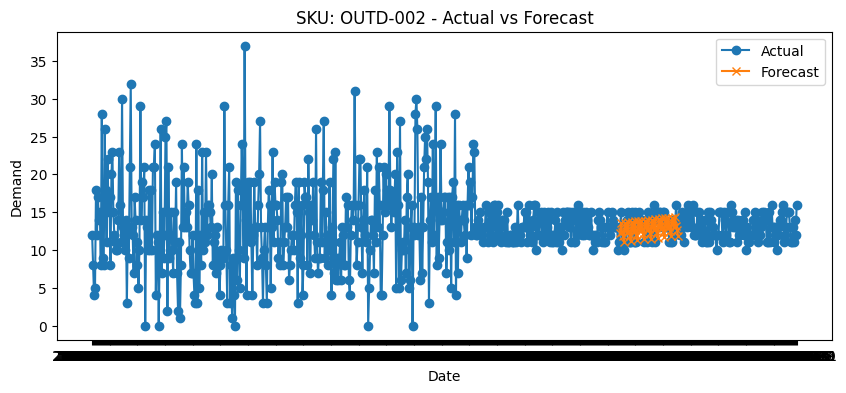

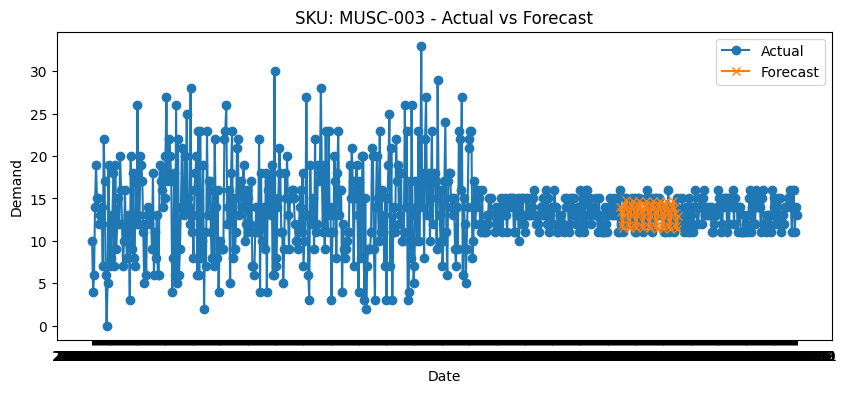

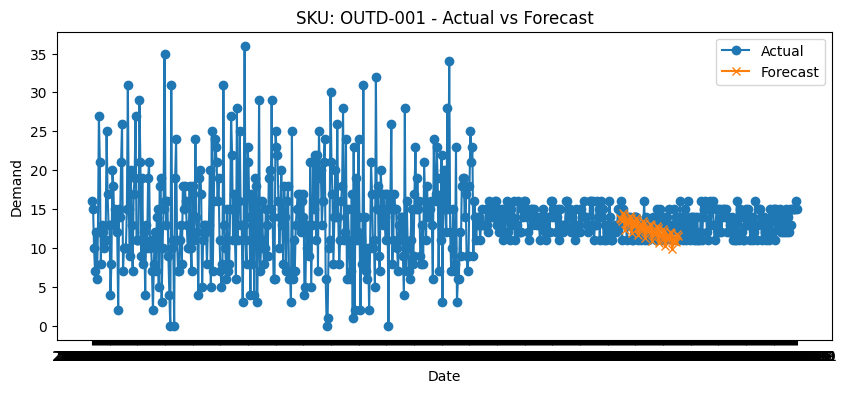

MAE: 1.38, RMSE: 1.73


In [8]:
# Load forecast and actuals
try:
    df_forecast = pd.read_csv('../data/processed/forecast_2025.csv')
    df_actual = pd.read_csv('../data/processed/daily_demand.csv')
except Exception as e:
    print(f"Error loading files: {e}")
    df_forecast = pd.DataFrame()
    df_actual = pd.DataFrame()

# Standardize column names to lowercase
df_forecast.columns = [c.lower() for c in df_forecast.columns]
df_actual.columns = [c.lower() for c in df_actual.columns]

# Try to find the forecast column name (could be 'forecast', 'forecast_demand', etc.)
forecast_col = None
for col in ['forecast', 'forecast_demand', 'yhat', 'predicted', 'prediction']:
    if col in df_forecast.columns:
        forecast_col = col
        break

if forecast_col is None:
    print("Could not find a forecast column in df_forecast. Columns are:", df_forecast.columns.tolist())

# Pick a few SKUs to visualize
sample_skus = df_forecast['sku'].unique()[:3] if 'sku' in df_forecast.columns else []

for sku in sample_skus:
    plt.figure(figsize=(10,4))
    actual = df_actual[df_actual['sku'] == sku]
    forecast = df_forecast[df_forecast['sku'] == sku]
    if not actual.empty and not forecast.empty and forecast_col is not None:
        plt.plot(actual['date'], actual['demand'], label='Actual', marker='o')
        plt.plot(forecast['date'], forecast[forecast_col], label='Forecast', marker='x')
        plt.title(f'SKU: {sku} - Actual vs Forecast')
        plt.xlabel('Date')
        plt.ylabel('Demand')
        plt.legend()
        plt.show()
    else:
        print(f"No data for SKU {sku} in one of the files or forecast column missing.")

# Forecast accuracy metrics (if actuals available for forecast period)
if not df_forecast.empty and not df_actual.empty and forecast_col is not None:
    merge_cols = ['date', 'sku']
    if all(col in df_forecast.columns for col in merge_cols) and all(col in df_actual.columns for col in merge_cols):
        merged = pd.merge(df_forecast, df_actual, on=merge_cols, how='inner')
        if not merged.empty:
            mae = mean_absolute_error(merged['demand'], merged[forecast_col])
            # Compute RMSE manually for compatibility with older sklearn versions
            mse = mean_squared_error(merged['demand'], merged[forecast_col])
            rmse = mse ** 0.5
            print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")
        else:
            print("No overlapping dates between forecast and actuals for metric calculation.")
    else:
        print("Required columns ['date', 'sku'] not found in both files. Columns in forecast:", df_forecast.columns.tolist(), "Columns in actuals:", df_actual.columns.tolist())

## 4. Drift Detection & Data Quality
- Show drift detection results and metrics.
- Visualize drift over time if available.
- Summarize data quality checks.

In [9]:
# Load drift and data quality metrics
try:
    df_metrics = pd.read_csv('../data/processed/metrics.csv')
    display(df_metrics.head())
    if 'drift_score' in df_metrics.columns:
        plt.figure(figsize=(10,4))
        plt.plot(df_metrics['date'], df_metrics['drift_score'], marker='o')
        plt.title('Drift Score Over Time')
        plt.xlabel('Date')
        plt.ylabel('Drift Score')
        plt.show()
except Exception as e:
    print(f"Could not load metrics.csv: {e}")

try:
    df_quality = pd.read_csv('../data/processed/data_quality.csv')
    display(df_quality.head())
except Exception as e:
    print(f"Could not load data_quality.csv: {e}")

,Date,SKU,Actual,Predicted,MAE,MAPE,RMSE,Drift,Retrained
0,2025-03-03,OUTD-003,12,19.0,7.0,58.3334,7.0,0,0
1,2025-03-03,OUTD-002,14,14.0,0.0,0.0000,0.0,0,0
2,2025-03-03,OUTD-001,15,7.0,8.0,53.3333,8.0,0,0
3,2025-03-03,OFFC-003,14,19.0,5.0,35.7143,5.0,0,0
4,2025-03-03,OFFC-002,14,14.0,0.0,0.0000,0.0,0,0


,sku,date,issues,pass
0,OUTD-003,2025-03-03,[],True
1,OUTD-002,2025-03-03,[],True
2,OUTD-001,2025-03-03,[],True
3,OFFC-003,2025-03-03,[],True
4,OFFC-002,2025-03-03,[],True


## 5. Inventory & Recommendations
- Show inventory_master.csv and inventory_recommendations.csv.
- Visualize inventory status distribution.
- Highlight a few example recommendations.

In [10]:
# Load inventory and recommendations
try:
    df_inventory = pd.read_csv('../data/processed/inventory_master.csv')
    display(df_inventory.head())
    if 'status' in df_inventory.columns:
        status_counts = df_inventory['status'].value_counts()
        status_counts.plot(kind='bar', color=['green', 'orange', 'red'])
        plt.title('Inventory Status Distribution')
        plt.xlabel('Status')
        plt.ylabel('Count')
        plt.show()
except Exception as e:
    print(f"Could not load inventory_master.csv: {e}")

try:
    df_recs = pd.read_csv('../data/processed/inventory_recommendations.csv')
    display(df_recs.head(10))
except Exception as e:
    print(f"Could not load inventory_recommendations.csv: {e}")

,SKU,Current_Stock,In_Transit,Lead_Time_Days,Safety_Stock,Stock_As_Of_Date
0,APPL-001,21,0,5,10,2026-04-15
1,PETS-001,37,0,5,10,2026-04-15
2,PCAR-003,38,0,7,10,2026-04-15
3,PCAR-002,24,0,10,10,2026-04-15
4,BABY-002,44,0,7,10,2026-04-15


,Date,SKU,Current_Stock,In_Transit,Recommended_Order_Qty,Risk_Level,Lead_Time_Days,Safety_Stock
0,2025-03-03,OUTD-003,76,0,29,WARNING,5,10
1,2025-03-03,OUTD-002,38,0,112,CRITICAL,10,10
2,2025-03-03,OUTD-001,5,0,40,WARNING,5,10
3,2025-03-03,OFFC-003,69,0,36,WARNING,5,10
4,2025-03-03,OFFC-002,46,0,104,CRITICAL,10,10
5,2025-03-03,OFFC-001,26,0,68,WARNING,5,10
6,2025-03-03,MUSC-003,61,0,98,WARNING,10,10
7,2025-03-03,MUSC-002,22,0,79,WARNING,7,10
8,2025-03-03,MOVI-001,27,0,66,WARNING,7,10
9,2025-03-03,MOVI-003,39,0,80,WARNING,10,10


## 6. Summary & Discussion
- Summarize key findings from each section.
- Discuss limitations, next steps, and reproducibility.
- Add any additional comments for research reporting.

---

*This notebook provides a full, reproducible overview of the demand forecasting, drift detection, and inventory pipeline. All outputs are generated from the latest pipeline run. For questions or reproducibility, see the README and pipeline scripts.*